In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Transform: Convert images to tensor
transform = transforms.ToTensor()

# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Create DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


root='./data' → where MNIST will be stored

train=True → use training dataset

download=True → automatically download dataset

batch_size=128 → 128 images per training step

shuffle=True → shuffle dataset every epoch

In [3]:
# variational Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(Encoder, self).__init__()

        # First layer
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Output layers for mean and log variance
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):

        # Flatten image (28x28 -> 784)
        x = x.view(-1, 784)

        h = torch.relu(self.fc1(x))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

In [5]:
# Raparameterize
def reparameterize(mu, logvar):

    # Convert log variance to standard deviation
    std = torch.exp(0.5 * logvar)

    # Sample epsilon from normal distribution
    eps = torch.randn_like(std)

    # Reparameterization trick
    z = mu + eps * std

    return z

### Reparameterization Trick (Sampling z)

The encoder outputs:

- μ (mean)
- log(σ²) (log variance)

We want to sample a latent vector:
z∼N(μ,σ2)
- But direct sampling breaks backpropagation.

So we use the Reparameterization Trick:
z=μ+σ×ϵ

where, ϵ∼N(0,1)

#### Decoder Flow:

<pre>
 z (latent vector: 20)
         ↓
       Linear
         ↓
       ReLU
         ↓
      Linear
         ↓
      Sigmoid
         ↓
Reconstructed Image (784)
</pre>

In [6]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super(Decoder, self).__init__()

        # First layer
        self.fc1 = nn.Linear(latent_dim, hidden_dim)

        # Output layer
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):

        h = torch.relu(self.fc1(z))

        x_reconstructed = torch.sigmoid(self.fc2(h))

        return x_reconstructed

<pre>
Input Image
     ↓
   Encoder
  ↓      ↓
 μ      logσ²
     ↓
Reparameterization
     ↓
      z
     ↓
   Decoder
     ↓
Reconstructed Image
</pre>

In [7]:
def vae_loss(x_reconstructed, x, mu, logvar):

    # Flatten input for BCE
    x = x.view(-1, 784)

    # Reconstruction loss
    recon_loss = nn.functional.binary_cross_entropy(x_reconstructed, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total VAE loss
    loss = recon_loss + kl_loss

    return loss, recon_loss, kl_loss

<pre>
VAE Loss Function

The total VAE loss has two parts:
1️⃣ Reconstruction Loss – measures how close the output image is to the input.
- We can use Binary Cross-Entropy (BCE) for MNIST, because pixel values are     between 0 and 1.
2️⃣ KL Divergence Loss – regularizes the latent space to follow a standard normal distribution
- N(0,1).
- KL(q(z∣x)∣∣p(z))=−0.5∑(1+log(σ2)−μ2−σ2)

In [10]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, logvar

In [11]:
# Initialize the VAE model
model = VAE()

# If GPU is available, move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [12]:
# Hyperparameters
learning_rate = 1e-3
num_epochs = 5

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(num_epochs):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for batch_idx, (x, _) in enumerate(train_loader):

        # Move data to device if GPU is available
        x = x

        # Forward pass
        x_reconstructed, mu, logvar = model(x)

        # Compute loss
        loss, recon_loss, kl_loss = vae_loss(x_reconstructed, x, mu, logvar)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate losses
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    # Print average loss per epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {total_loss/len(train_loader.dataset):.4f}, "
          f"Reconstruction: {total_recon/len(train_loader.dataset):.4f}, "
          f"KL Divergence: {total_kl/len(train_loader.dataset):.4f}")

Epoch [1/5], Loss: 163.9756, Reconstruction: 148.0781, KL Divergence: 15.8975
Epoch [2/5], Loss: 121.2491, Reconstruction: 98.5886, KL Divergence: 22.6605
Epoch [3/5], Loss: 114.7196, Reconstruction: 90.5959, KL Divergence: 24.1237
Epoch [4/5], Loss: 111.7206, Reconstruction: 87.0002, KL Divergence: 24.7204
Epoch [5/5], Loss: 109.9508, Reconstruction: 84.9435, KL Divergence: 25.0073



### Observations
- Loss decreasing → training is working.
- Reconstruction loss decreasing faster than KL → model is learning to reconstruct first, then balancing KL regularization.
- The numbers seem reasonable for a simple VAE on MNIST.


<pre>
Visualize Reconstructed Images
1️). Take a batch of test images
2️). Pass them through the VAE
3️). Compare the original vs reconstructed images
</pre>

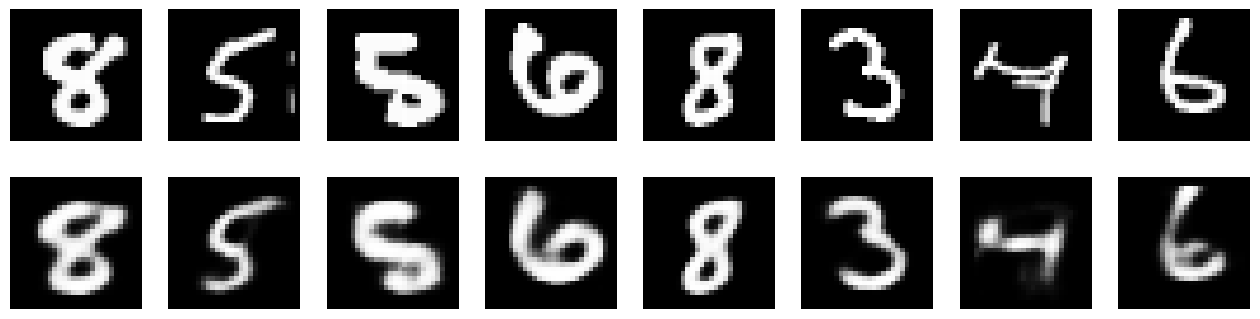

In [13]:
import matplotlib.pyplot as plt

# Get one batch from the train loader
x, _ = next(iter(train_loader))
x = x.to(device)

# Reconstruct images
model.eval()
with torch.no_grad():
    x_reconstructed, _, _ = model(x)

# Convert tensors to CPU for plotting
x = x.cpu()
x_reconstructed = x_reconstructed.cpu()

# Plot original vs reconstructed
n = 8  # number of images to display
plt.figure(figsize=(16,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap='gray')
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_reconstructed[i].view(28,28), cmap='gray')
    ax.axis('off')

plt.show()

### Generate New MNIST Digits from Latent Space

- A VAE learns a latent space where each point corresponds to a possible image.
We can sample z ~ N(0,1) and pass it through the decoder to generate new digits.

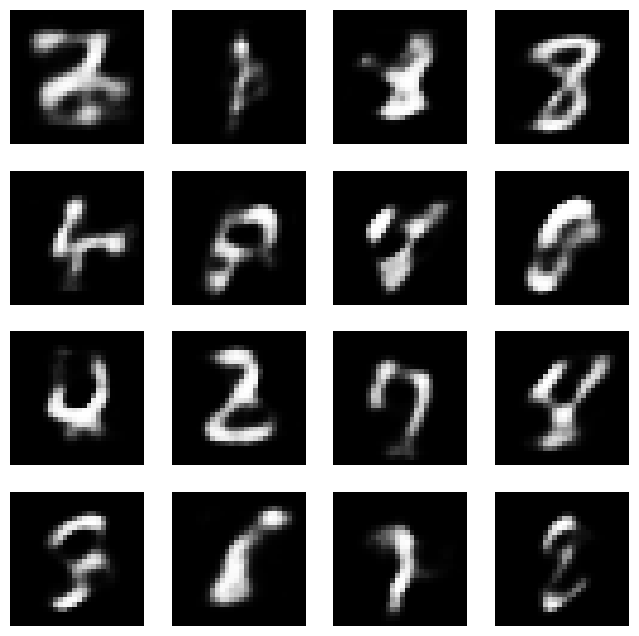

In [14]:
# Number of new images to generate
num_samples = 16

# Sample random latent vectors from standard normal
z = torch.randn(num_samples, 20).to(device)  # latent_dim = 20

# Decode to generate images
model.eval()
with torch.no_grad():
    generated = model.decoder(z)

# Move to CPU for plotting
generated = generated.cpu()

# Plot the generated digits
plt.figure(figsize=(8, 8))
for i in range(num_samples):
    ax = plt.subplot(4, 4, i+1)
    plt.imshow(generated[i].view(28,28), cmap='gray')
    ax.axis('off')
plt.show()